<a href="https://colab.research.google.com/github/nipuninduwaraedu/SE4050-Assignment-/blob/model_CNN/CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
#Import libraries
import os
import json
import time
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [8]:
#Set random seed
SEED = 42

np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

print("Random seed:", SEED)


Random seed: 42


In [9]:
#Connect Google Drive
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
#Load prepared dataset
import os
import numpy as np

DATA_PATH = "/content/drive/MyDrive/ SE4050-HAR/prepared_har_data.npz"

data = np.load(
    DATA_PATH,
    allow_pickle=True
)

X_train = data["X_train"]
y_train = data["y_train"]

X_val = data["X_validation"]
y_val = data["y_validation"]

X_test = data["X_test"]
y_test = data["y_test"]

if "activity_names" in data.files:
    activity_names = data["activity_names"]
else:
    activity_names = np.array(["WALKING", "WALKING_UPSTAIRS", "WALKING_DOWNSTAIRS", "SITTING", "STANDING", "LAYING"])

print("🎉 DATASET LOADED SUCCESSFULLY")
print(f"X_train shape:      {X_train.shape}")
print(f"X_validation shape: {X_val.shape}")
print(f"X_test shape:       {X_test.shape}")


🎉 DATASET LOADED SUCCESSFULLY
X_train shape:      (5551, 128, 9)
X_validation shape: (1801, 128, 9)
X_test shape:       (2947, 128, 9)


In [11]:
# check shapes
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (5551, 128, 9)
y_train: (5551,)
X_val: (1801, 128, 9)
y_val: (1801,)
X_test: (2947, 128, 9)
y_test: (2947,)


In [12]:
# check classes
print("Classes:", np.unique(y_train))
print("Activity names:", activity_names)

Classes: [0 1 2 3 4 5]
Activity names: ['WALKING' 'WALKING_UPSTAIRS' 'WALKING_DOWNSTAIRS' 'SITTING' 'STANDING'
 'LAYING']


In [13]:
# verify input shapes
assert X_train.ndim == 3
assert X_train.shape[1] == 128
assert X_train.shape[2] == 9

assert X_val.shape[1:] == (128, 9)
assert X_test.shape[1:] == (128, 9)

print("Input shape verification passed.")

Input shape verification passed.


In [14]:
# verify no Nan/Inf

print("NaN in X_train:", np.isnan(X_train).any())
print("NaN in X_val:", np.isnan(X_val).any())
print("NaN in X_test:", np.isnan(X_test).any())

print("Inf in X_train:", np.isinf(X_train).any())
print("Inf in X_val:", np.isinf(X_val).any())
print("Inf in X_test:", np.isinf(X_test).any())

NaN in X_train: False
NaN in X_val: False
NaN in X_test: False
Inf in X_train: False
Inf in X_val: False
Inf in X_test: False


In [15]:
# import keras layer
from tensorflow.keras import Sequential

from tensorflow.keras.layers import (
    Input,
    Conv1D,
    MaxPooling1D,
    Flatten,
    Dense,
    Dropout
)

In [16]:
# create CNN
model = Sequential([

    Input(shape=(128, 9)),

    Conv1D(
        filters=64,
        kernel_size=5,
        activation="relu"
    ),

    MaxPooling1D(
        pool_size=2
    ),

    Conv1D(
        filters=128,
        kernel_size=5,
        activation="relu"
    ),

    MaxPooling1D(
        pool_size=2
    ),

    Flatten(),

    Dense(
        128,
        activation="relu"
    ),

    Dropout(
        0.5
    ),

    Dense(
        6,
        activation="softmax"
    )
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 124, 64)        │         2,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 62, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 58, 128)        │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 29, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3712)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       475,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 520,070 (1.98 MB)

 Trainable params: 520,070 (1.98 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
# compile
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]
)

In [18]:
# early stopping
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [19]:
# train
start_time = time.time()

history = model.fit(
    X_train,
    y_train,

    validation_data=(
        X_val,
        y_val
    ),

    epochs=30,

    batch_size=64,

    callbacks=[
        early_stopping
    ],

    verbose=1
)

training_time = time.time() - start_time

print(
    f"Training time: {training_time:.2f} seconds"
)

Epoch 1/30
87/87 ━━━━━━━━━━━━━━━━━━━━ 7s 59ms/step - accuracy: 0.8087 - loss: 0.5093 - val_accuracy: 0.9795 - val_loss: 0.0961
Epoch 2/30
87/87 ━━━━━━━━━━━━━━━━━━━━ 11s 72ms/step - accuracy: 0.9341 - loss: 0.1622 - val_accuracy: 0.9733 - val_loss: 0.0939
Epoch 3/30
87/87 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - accuracy: 0.9469 - loss: 0.1257 - val_accuracy: 0.9561 - val_loss: 0.1142
Epoch 4/30
87/87 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - accuracy: 0.9467 - loss: 0.1157 - val_accuracy: 0.9745 - val_loss: 0.1098
Epoch 5/30
87/87 ━━━━━━━━━━━━━━━━━━━━ 5s 60ms/step - accuracy: 0.9517 - loss: 0.1084 - val_accuracy: 0.9539 - val_loss: 0.1939
Epoch 6/30
87/87 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - accuracy: 0.9524 - loss: 0.1034 - val_accuracy: 0.9767 - val_loss: 0.0880
Epoch 7/30
87/87 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.9578 - loss: 0.0907 - val_accuracy: 0.9667 - val_loss: 0.1216
Epoch 8/30
87/87 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step - accuracy: 0.9553 - loss: 0.1090 - val_accuracy: 0.9622 - 

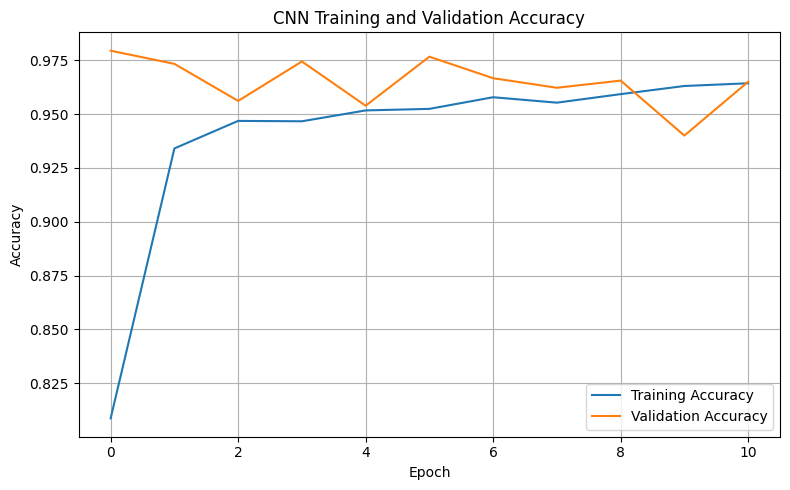

In [20]:
# accuracy
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "CNN Training and Validation Accuracy"
)

plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "/content/cnn_training_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

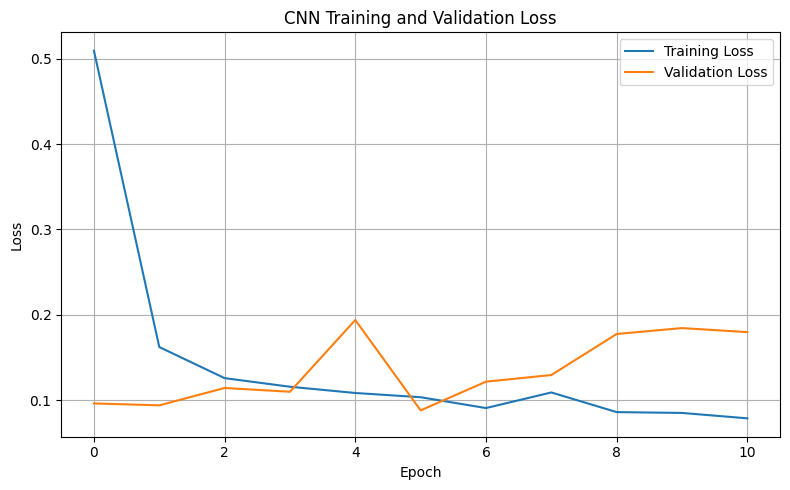

In [21]:
# Loss
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "CNN Training and Validation Loss"
)

plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "/content/cnn_training_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [23]:
# test
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

Test Loss: 0.2702367603778839
Test Accuracy: 0.9229725003242493


In [24]:
# prediction
y_probability = model.predict(
    X_test,
    verbose=0
)

y_pred = np.argmax(
    y_probability,
    axis=1
)

print("Predictions generated.")

Predictions generated.


In [25]:
# metrics
accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    average="macro"
)

recall = recall_score(
    y_test,
    y_pred,
    average="macro"
)

f1 = f1_score(
    y_test,
    y_pred,
    average="macro"
)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

Accuracy : 0.9230
Precision: 0.9254
Recall   : 0.9234
F1-score : 0.9231


In [26]:
# classification
report = classification_report(
    y_test,
    y_pred,
    target_names=activity_names
)

print(report)

                    precision    recall  f1-score   support

           WALKING       0.99      1.00      0.99       496
  WALKING_UPSTAIRS       0.97      0.95      0.96       471
WALKING_DOWNSTAIRS       0.94      0.97      0.95       420
           SITTING       0.86      0.74      0.79       491
          STANDING       0.80      0.89      0.84       532
            LAYING       0.99      1.00      1.00       537

          accuracy                           0.92      2947
         macro avg       0.93      0.92      0.92      2947
      weighted avg       0.92      0.92      0.92      2947



In [27]:
# save
with open(
    "/content/cnn_classification_report.txt",
    "w"
) as file:

    file.write(report)

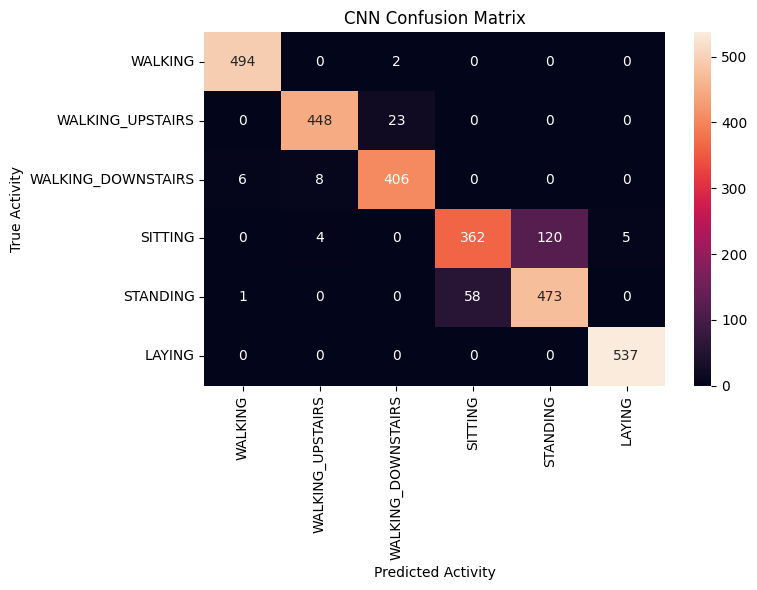

In [28]:
# confusion matrix
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=activity_names,
    yticklabels=activity_names
)

plt.xlabel("Predicted Activity")
plt.ylabel("True Activity")

plt.title(
    "CNN Confusion Matrix"
)

plt.tight_layout()

plt.savefig(
    "/content/cnn_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [29]:
# vparameter count
parameter_count = model.count_params()

print(
    "Total parameters:",
    parameter_count
)

Total parameters: 520070


In [30]:
# training information
epochs_trained = len(
    history.history["loss"]
)

print("Epochs trained:", epochs_trained)
print("Training time:", training_time)
print("Parameters:", parameter_count)

Epochs trained: 11
Training time: 58.5036461353302
Parameters: 520070


In [31]:
# save all
cnn_results = {

    "model": "1D CNN",

    "random_seed": SEED,

    "input_shape": [
        int(X_train.shape[1]),
        int(X_train.shape[2])
    ],

    "number_of_classes": 6,

    "optimizer": "Adam",

    "learning_rate": 0.001,

    "loss_function": "sparse_categorical_crossentropy",

    "batch_size": 64,

    "maximum_epochs": 30,

    "epochs_trained": epochs_trained,

    "early_stopping": True,

    "early_stopping_patience": 5,

    "test_accuracy": float(accuracy),

    "test_precision_macro": float(precision),

    "test_recall_macro": float(recall),

    "test_f1_macro": float(f1),

    "training_time_seconds": float(training_time),

    "parameter_count": int(parameter_count)
}

In [32]:
# save Json
with open(
    "/content/cnn_results.json",
    "w"
) as file:

    json.dump(
        cnn_results,
        file,
        indent=4
    )

print(
    json.dumps(
        cnn_results,
        indent=4
    )
)

{
    "model": "1D CNN",
    "random_seed": 42,
    "input_shape": [
        128,
        9
    ],
    "number_of_classes": 6,
    "optimizer": "Adam",
    "learning_rate": 0.001,
    "loss_function": "sparse_categorical_crossentropy",
    "batch_size": 64,
    "maximum_epochs": 30,
    "epochs_trained": 11,
    "early_stopping": true,
    "early_stopping_patience": 5,
    "test_accuracy": 0.9229725144214456,
    "test_precision_macro": 0.9253758566625857,
    "test_recall_macro": 0.923361792827432,
    "test_f1_macro": 0.9230894216695652,
    "training_time_seconds": 58.5036461353302,
    "parameter_count": 520070
}


In [33]:
# save model
model.save(
    "/content/cnn_model.keras"
)

print("CNN model saved.")

CNN model saved.


In [36]:
# download
from google.colab import files

files.download(
    "/content/cnn_model.keras"
)

files.download(
    "/content/cnn_training_accuracy.png"
)

files.download(
    "/content/cnn_training_loss.png"
)

files.download(
    "/content/cnn_confusion_matrix.png"
)

files.download(
    "/content/cnn_classification_report.txt"
)

files.download(
    "/content/cnn_training_loss.png"
)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>